In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [2]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

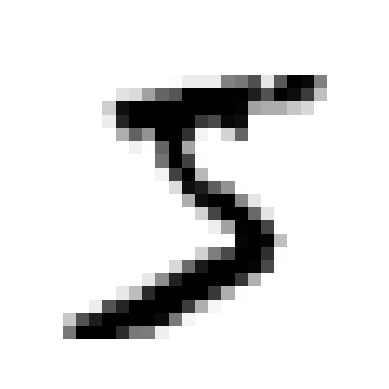

In [3]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')

some_digit = X[0]
plot_digit(some_digit)

plt.show()

In [4]:
y[0]

'5'

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

In [6]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)

y_pred = lr_clf.predict(X_test)
y_pred

c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array(['2', '4', '0', ..., '3', '0', '8'], shape=(35000,), dtype=object)

In [7]:
y_test

array(['2', '4', '0', ..., '3', '0', '8'], shape=(35000,), dtype=object)

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[3270,    0,   16,    5,    7,   28,   27,    8,   20,    6],
       [   0, 3816,   21,    9,    5,   10,    8,    8,   32,    8],
       [  31,   43, 3072,   73,   48,   12,   49,   47,   66,   16],
       [  16,   12,   86, 3206,    3,  131,   12,   40,   76,   27],
       [  12,   14,   17,    6, 3167,    4,   31,    8,   37,  116],
       [  46,   13,   25,  133,   23, 2654,   59,   14,   99,   25],
       [  26,   12,   33,    3,   40,   41, 3358,    8,   15,    3],
       [  12,    8,   43,   20,   40,    7,    2, 3389,   10,  152],
       [  24,   65,   52,  102,    9,  110,   26,   21, 2954,   49],
       [  17,   17,    8,   48,   92,   25,    1,  105,   24, 3156]])

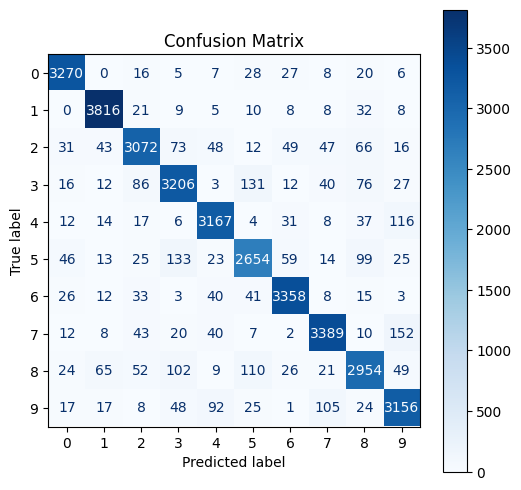

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_clf.classes_)
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [10]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=123)
sgd_clf.fit(X_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


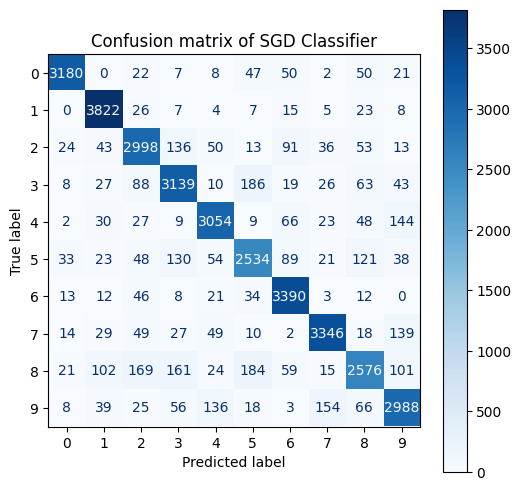

In [11]:
y_pred = sgd_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sgd_clf.classes_)
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion matrix of SGD Classifier')
plt.show()

In [12]:
import numpy as np

Dio_Sum = 0

for i in range(10):
    Dio_Sum += cm[i, i]

accuracy = Dio_Sum / np.sum(cm)

accuracy

np.float64(0.8864857142857143)

In [13]:
from sklearn.metrics import accuracy_score

print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Manually: ', np.trace(cm) / np.sum(cm))

Accuracy:  0.8864857142857143
Manually:  0.8864857142857143


In [60]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.4f}")

Balanced Accuracy: 0.8843


* True Positives (TP): The diagonal elements.
e.g., 
.
These are cases where the actual class and predicted class are the same.
* False Positives (FP): The sum of the corresponding column (excluding the diagonal)
e.g., 
.
This means the model predicted this class, but it was actually another class.
* False Negatives (FN): The sum of the corresponding row (excluding the diagonal).
e.g., 
.
This means the actual class was this one, but the model predicted a different class
* True Negative (TN): The sum of all elements in the confusion matrix that do not belong to that class's row or column.
e.g., 
.
These are cases where the actual class was "not X" and the model correctly predicted "not X."

In [62]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=sgd_clf.classes_))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      3387
           1       0.93      0.98      0.95      3917
           2       0.86      0.87      0.86      3457
           3       0.85      0.87      0.86      3609
           4       0.90      0.90      0.90      3412
           5       0.83      0.82      0.83      3091
           6       0.90      0.96      0.93      3539
           7       0.92      0.91      0.91      3683
           8       0.85      0.75      0.80      3412
           9       0.85      0.86      0.86      3493

    accuracy                           0.89     35000
   macro avg       0.89      0.88      0.88     35000
weighted avg       0.89      0.89      0.89     35000



### Practice to get Confusion matrix

In [ ]:
import pandas as pd

df = pd.DataFrame([[1, 1, 1], [2, 1, 1], [3, 1, 0], [4, 1, 1], [5, 0, 0],
                   [6, 0, 1], [7, 0, 0], [8, 0, 0], [9, 0, 1], [10, 1, 0]],
                   columns=['Sample', 'Actual', 'Predicted'])

In [50]:
df

,Sample,Actual,Predicted
0,1,1,1
1,2,1,1
2,3,1,0
3,4,1,1
4,5,0,0
5,6,0,1
6,7,0,0
7,8,0,0
8,9,0,1
9,10,1,0


In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_ex = confusion_matrix(df['Predicted'], df['Actual'])

cm_ex

array([[3, 2],
       [2, 3]])

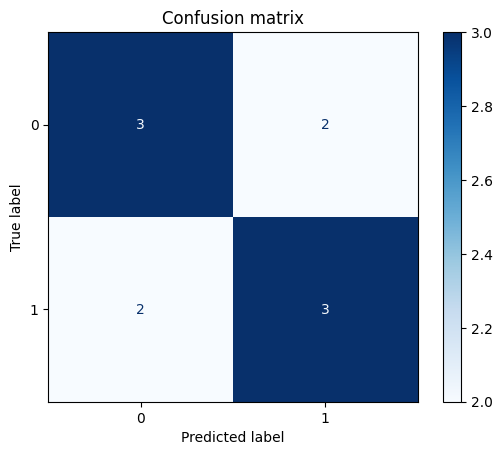

In [59]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ex)
disp.plot(cmap='Blues')
plt.title('Confusion matrix')
plt.show()

In [63]:
print(classification_report(df['Predicted'], df['Actual']))

              precision    recall  f1-score   support

           0       0.60      0.60      0.60         5
           1       0.60      0.60      0.60         5

    accuracy                           0.60        10
   macro avg       0.60      0.60      0.60        10
weighted avg       0.60      0.60      0.60        10

